# Column Detection on Sample Data

First, we will load in the set of sample tables.

In [4]:
from torchvision import transforms
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageOps

#| export
from huggingface_hub import hf_hub_download
from transformers import AutoModelForObjectDetection
import torch
from PIL import Image
import os

In [1]:
tables_folder = "images"

In [2]:
out_folder = "tables"

In [5]:
table_paths = []
for folder in os.listdir(out_folder):
    tpage = os.path.join(out_folder, folder)
    for table in os.listdir(tpage):
        table_paths.append(os.path.join(tpage, table))

## Load the model for column detection

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForObjectDetection.from_pretrained("microsoft/table-transformer-structure-recognition", revision="no_timm")

Apply the same preprocessing that we did in the table detection.

In [14]:
import numpy as np
import cv2
from PIL import Image
from torchvision import transforms

class MaxResize(object):
    def __init__(self, max_size=800):
        self.max_size = max_size

    def __call__(self, image):
        width, height = image.size
        current_max_size = max(width, height)
        scale = self.max_size / current_max_size
        resized_image = image.resize((int(round(scale * width)), int(round(scale * height))), Image.Resampling.LANCZOS)
        return resized_image

class ToGrayscale(object):
    def __call__(self, img):
        return img.convert("L")

class ApplyThresholding(object):
    def __call__(self, img):
        img_cv = np.array(img)
        if len(img_cv.shape) == 3:  # Convert to grayscale if it's not already
            img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2GRAY)
        _, img_thresh = cv2.threshold(img_cv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return Image.fromarray(img_thresh)

class ApplyDilation(object):
    def __init__(self, kernel_size=3):
        self.kernel = np.ones((kernel_size, kernel_size), np.uint8)

    def __call__(self, img):
        img_cv = np.array(img)
        img_dilated = cv2.dilate(img_cv, self.kernel, iterations=1)
        return Image.fromarray(img_dilated)

class EnhanceContrast(object):
    def __call__(self, img):
        img_cv = np.array(img)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_enhanced = clahe.apply(img_cv)
        return Image.fromarray(img_enhanced)

class EdgeDetection(object):
    def __call__(self, img):
        img_cv = np.array(img)
        edges = cv2.Canny(img_cv, 100, 200)
        return Image.fromarray(edges)

class GrayscaleTo3Channel(object):
    def __call__(self, img):
        img_array = np.array(img)
        if len(img_array.shape) == 2:  # If grayscale
            img_3ch = np.stack([img_array] * 3, axis=-1)
            return Image.fromarray(img_3ch)
        else:
            return img  # If already 3-channel, return as is
        
class ApplyErosion(object):
    def __init__(self, kernel_size=3):
        self.kernel = np.ones((kernel_size, kernel_size), np.uint8)

    def __call__(self, img):
        img_cv = np.array(img)
        img_eroded = cv2.erode(img_cv, self.kernel, iterations=1)
        return Image.fromarray(img_eroded)


class ToGrayscale(object):
    def __call__(self, img):
        return img.convert("L")

class ApplyGaussianBlur(object):
    def __init__(self, kernel_size=(5, 5), sigma=0):
        self.kernel_size = kernel_size
        self.sigma = sigma

    def __call__(self, img):
        img_cv = np.array(img)
        blurred_img = cv2.GaussianBlur(img_cv, self.kernel_size, self.sigma)
        return Image.fromarray(blurred_img)

class CannyEdgeDetection(object):
    def __init__(self, low_threshold=50, high_threshold=150):
        self.low_threshold = low_threshold
        self.high_threshold = high_threshold

    def __call__(self, img):
        img_cv = np.array(img)
        edges = cv2.Canny(img_cv, self.low_threshold, self.high_threshold)
        return Image.fromarray(edges)

class ApplyDilation(object):
    def __init__(self, kernel_size=3, iterations=1):
        self.kernel = np.ones((kernel_size, kernel_size), np.uint8)
        self.iterations = iterations

    def __call__(self, img):
        img_cv = np.array(img)
        img_dilated = cv2.dilate(img_cv, self.kernel, iterations=self.iterations)
        return Image.fromarray(img_dilated)

class HoughLineTransform(object):
    def __init__(self, rho=1, theta=np.pi/180, threshold=100, min_line_length=100, max_line_gap=10):
        self.rho = rho
        self.theta = theta
        self.threshold = threshold
        self.min_line_length = min_line_length
        self.max_line_gap = max_line_gap

    def __call__(self, img, original_img):
        img_cv = np.array(img)
        lines = cv2.HoughLinesP(img_cv, self.rho, self.theta, self.threshold, 
                                minLineLength=self.min_line_length, maxLineGap=self.max_line_gap)
        if lines is not None:
            for line in lines:
                for x1, y1, x2, y2 in line:
                    cv2.line(original_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        return Image.fromarray(original_img)

class MaxResize(object):
    def __init__(self, max_size=800):
        self.max_size = max_size

    def __call__(self, image):
        width, height = image.size
        current_max_size = max(width, height)
        scale = self.max_size / current_max_size
        resized_image = image.resize((int(round(scale * width)), int(round(scale * height))), Image.Resampling.LANCZOS)
        return resized_image

class DetectionTransformPipeline(object):
    def __init__(self):
        self.pipeline = transforms.Compose([
            ToGrayscale(),
            ApplyGaussianBlur(kernel_size=(5, 5), sigma=0),
            CannyEdgeDetection(low_threshold=50, high_threshold=150),
            ApplyDilation(kernel_size=3, iterations=1),
            MaxResize(800)
        ])

    def __call__(self, img):
        return self.pipeline(img)

    def detect_lines(self, img):
        # Convert original image to OpenCV format for drawing lines
        original_img = np.array(img.copy())
        edges_img = self.pipeline(img)
        hough_transform = HoughLineTransform()
        return hough_transform(edges_img, original_img)
    
# Example usage of the transform pipeline
detection_transform = transforms.Compose([
    ToGrayscale(),
    ApplyThresholding(),
    GrayscaleTo3Channel(),
    MaxResize(800),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.485, 0.485], [0.229, 0.229, 0.229])  # Same mean and std for each channel
])


Retrieval Function for the Bboxes

In [8]:
# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(-1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h), (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)


def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b


# update id2label to include "no object"
id2label = model.config.id2label
id2label[len(model.config.id2label)] = "no object"


def outputs_to_objects(outputs, img_size, id2label):
    m = outputs.logits.softmax(-1).max(-1)
    pred_labels = list(m.indices.detach().cpu().numpy())[0]
    pred_scores = list(m.values.detach().cpu().numpy())[0]
    pred_bboxes = outputs['pred_boxes'].detach().cpu()[0]
    pred_bboxes = [elem.tolist() for elem in rescale_bboxes(pred_bboxes, img_size)]

    objects = []
    for label, score, bbox in zip(pred_labels, pred_scores, pred_bboxes):
        class_label = id2label[int(label)]
        if not class_label == 'no object':
            objects.append({'label': class_label, 'score': float(score),
                            'bbox': [float(elem) for elem in bbox]})

    return objects

Finally, we will plot the columns to gain a visual of the model results.

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch

def fig2img(fig):
    """Convert a Matplotlib figure to a PIL Image and return it"""
    import io
    buf = io.BytesIO()
    fig.savefig(buf)
    buf.seek(0)
    img = Image.open(buf)
    return img


def visualize_detected_tables(img, det_tables, out_path=None, name = None):
    plt.imshow(img, interpolation="lanczos")
    fig = plt.gcf()
    fig.set_size_inches(20, 20)
    ax = plt.gca()

    for det_table in det_tables:
        bbox = det_table['bbox']

        if det_table['label'] == 'table column':
            facecolor = (1, 0, 0.45)
            edgecolor = (1, 0, 0.45)
            alpha = 0.3
            linewidth = 2
            hatch='//////'
        # if det_table['label'] == 'table row':
        #     facecolor = (0.95, 0.6, 0.1)
        #     edgecolor = (0.95, 0.6, 0.1)
        #     alpha = 0.3
        #     linewidth = 2
        #     hatch='//////'
        else:
            continue

        rect = patches.Rectangle(bbox[:2], bbox[2]-bbox[0], bbox[3]-bbox[1], linewidth=linewidth,
                                    edgecolor='none',facecolor=facecolor, alpha=0.1)
        ax.add_patch(rect)
        rect = patches.Rectangle(bbox[:2], bbox[2]-bbox[0], bbox[3]-bbox[1], linewidth=linewidth,
                                    edgecolor=edgecolor,facecolor='none',linestyle='-', alpha=alpha)
        ax.add_patch(rect)
        rect = patches.Rectangle(bbox[:2], bbox[2]-bbox[0], bbox[3]-bbox[1], linewidth=0,
                                    edgecolor=edgecolor,facecolor='none',linestyle='-', hatch=hatch, alpha=0.2)
        ax.add_patch(rect)

    plt.xticks([], [])
    plt.yticks([], [])

    legend_elements = [Patch(facecolor=(1, 0, 0.45), edgecolor=(1, 0, 0.45),
                                label='Table Column', hatch='//////', alpha=0.3),
                        Patch(facecolor=(0.95, 0.6, 0.1), edgecolor=(0.95, 0.6, 0.1),
                                label='Table Row', hatch='//////', alpha=0.3)]
    plt.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.02), loc='upper center', borderaxespad=0,
                    fontsize=10, ncol=2)
    plt.gcf().set_size_inches(10, 10)
    plt.axis('off')

    if out_path is not None:
        if not os.path.exists(out_path):
            os.makedirs(out_path)
        plt.savefig(os.path.join(out_path,name), bbox_inches='tight', dpi=150)
    
    plt.clf() 

    return fig

In [10]:
def runModel(files):
    file_path = []
    score_list = []
    for path in files:
        image = Image.open(path).convert("RGB")
        # Add a 1-pixel wide black border
        # bordered_image = ImageOps.expand(image, border=2, fill="black")
        pixelval = detection_transform(image).unsqueeze(0)
        pixelval = pixelval.to(device)
        with torch.no_grad():
            outputs = model(pixelval)
        objects = outputs_to_objects(outputs, image.size, id2label)
        file_path.append(path)
        score_list.append(objects)
    data = pd.DataFrame({"file_path":file_path, "score": score_list})
    data.to_csv("columnSample.csv", index=False)
    return data

In [15]:
mydf = runModel(table_paths)

In [12]:
def markTable(index, data):
    image_path = data["file_path"][index]
    object = data["score"][index]
    image = Image.open(image_path).convert("RGB")
    # making border around image using copyMakeBorder 
    visualize_detected_tables(image, object, out_path=os.path.join("results", image_path.split("/")[-2]), name = image_path.split("/")[-1])

In [16]:
for i in range(mydf.shape[0]):
    markTable(i, mydf)

<Figure size 1000x1000 with 0 Axes>

# Select Examples

Clear and distinct tables results in clean and desirable columns, below is an example for document 24284 page 20.

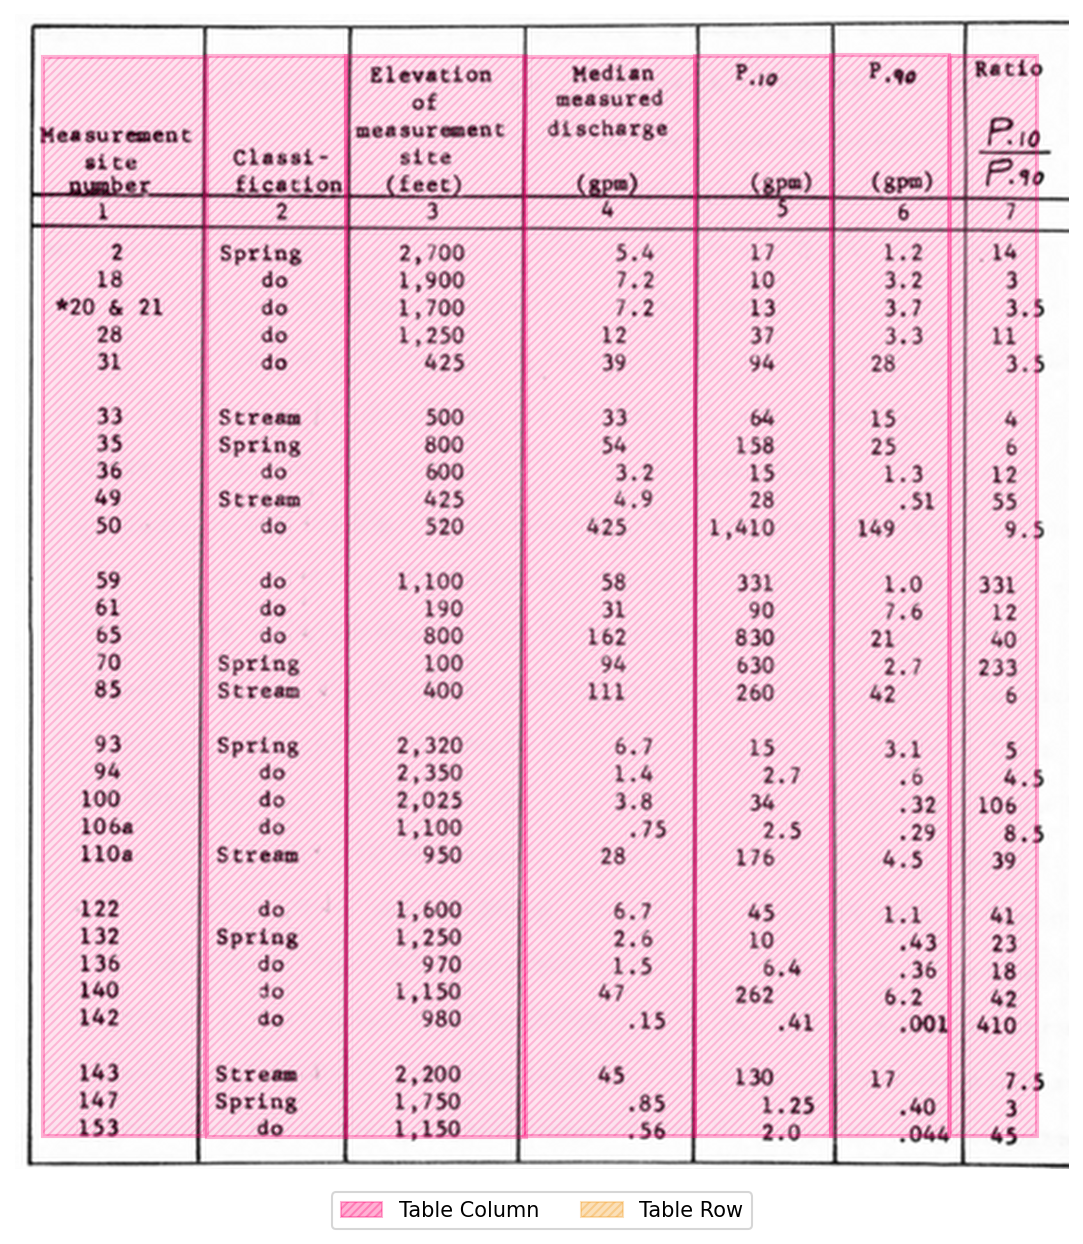

In [3]:
image = Image.open('tables/24284_page20.png/table_rotated_0_columns.png')
image

The main issue comes with cluttered tables. Tables with a lot of stacked numbers create a lot of noise. Below is an example of the noisy bounding box. Document 2344 page 41.

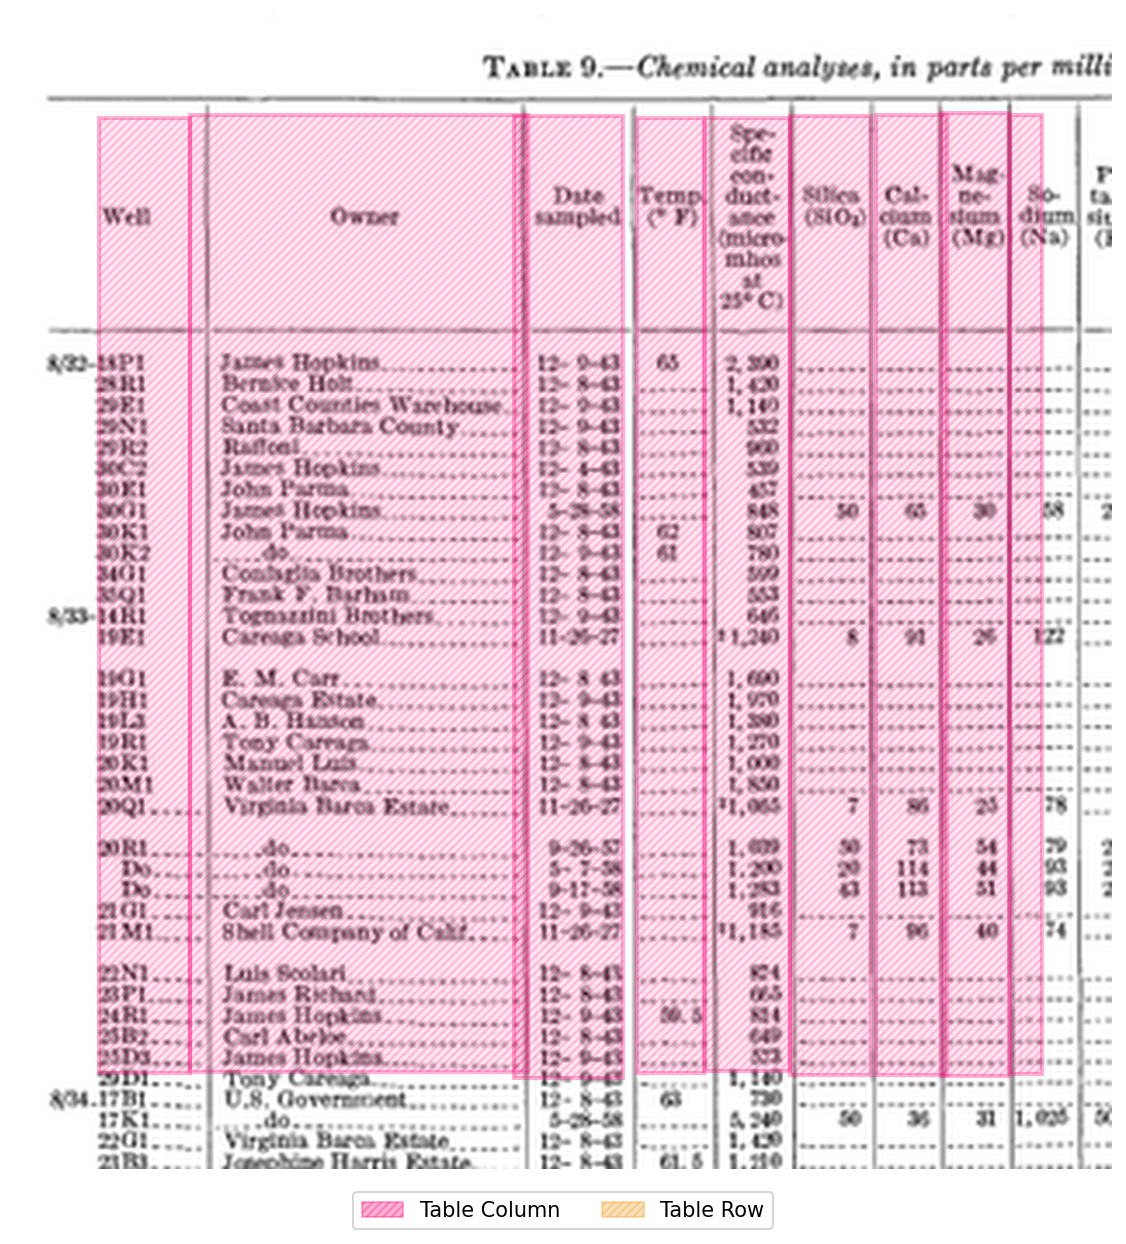

In [4]:
Image.open("tables/2344_page40.png/table_0_columns.png")

## Other Options: CV2 Line Detection 

In [18]:
# Load image, convert to grayscale, Otsu's threshold
image = cv2.imread('sampleTables/1166_page31.png')
result = image.copy()
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Detect horizontal lines
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (150,1))
detect_horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
cnts = cv2.findContours(detect_horizontal, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    cv2.drawContours(result, [c], -1, (36,255,12), 2)

# Detect vertical lines
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,6))
detect_vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vertical_kernel, iterations=2)
cnts = cv2.findContours(detect_vertical, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    cv2.drawContours(result, [c], -1, (36,255,12), 2)

cv2.imwrite("cv2LineDetection.png", result)

True

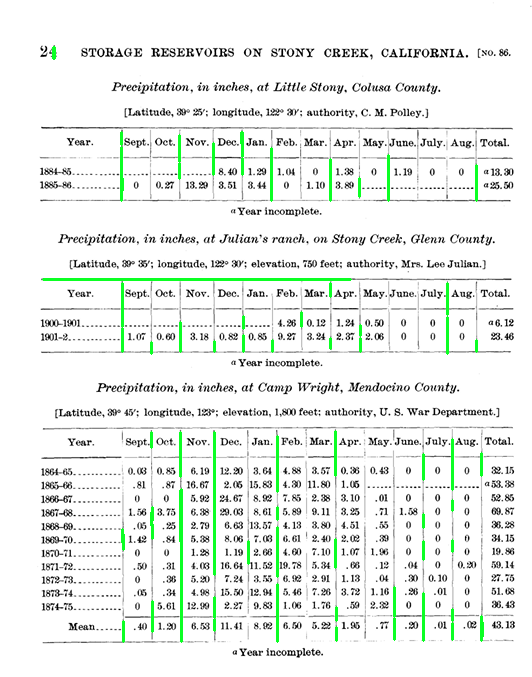

In [19]:
Image.open("cv2LineDetection.png")